# RASE-ECG v8: Fast Reliability-Aware Stacked ECG Ensemble
## Calibration, Explainability, and Edge-Deployable Decision Support

---

This complete notebook is an optimized version of the RASE-ECG workflow. It preserves the full pipeline—MIT-BIH loading, patient-level splitting, preprocessing, feature engineering, deep base learners, XGBoost, calibrated stacking, reliability analysis, explainability, deployment profiling, dashboard generation, and output export—while correcting the slow-training bottleneck observed in the CNN stage.

### Main corrections in this version

| Issue | Correction |
|---|---|
| Extremely slow CNN step on CPU/GPU | CNN self-attention block removed by default; lightweight residual CNN used |
| Unclear GPU status | Runtime device diagnostics added |
| Mixed precision on CPU | Mixed precision enabled only when a GPU is detected |
| Heavy training defaults | Fast complete mode with early stopping, larger batch size, prefetching, and smaller recurrent/transformer blocks |
| Reproducibility | All outputs still saved to Google Drive under `MyDrive/Outputs/RASE_ECG/` |

### Recommended Colab setting
Use **Runtime → Change runtime type → GPU** before running all cells.


## Section 1 — Installation & Imports

In [1]:
# ── Install required packages ──────────────────────────────────────────────
# Colab already provides TensorFlow in most runtimes. Reinstalling TensorFlow
# can slow the notebook and occasionally create version conflicts, so it is not
# force-installed here.
import sys, subprocess, importlib.util

packages = [
    'wfdb', 'scikit-learn', 'xgboost', 'shap',
    'matplotlib', 'seaborn', 'scipy', 'imbalanced-learn',
    'tqdm', 'pandas', 'numpy', 'joblib'
]

def _is_installed(pkg):
    name = pkg.replace('-', '_')
    if pkg == 'scikit-learn':
        name = 'sklearn'
    return importlib.util.find_spec(name) is not None

missing = [p for p in packages if not _is_installed(p)]
if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('All required non-TensorFlow packages are already available.')


Installing missing packages: ['wfdb', 'imbalanced-learn']


### Google Drive — mount & folder structure

All outputs are organised into sub-folders under `MyDrive/Outputs/RASE_ECG/`:

| Variable | Path | Content |
|---|---|---|
| `FIGURES_DIR` | `.../Figures/` | All `.png` plots |
| `TABLES_DIR` | `.../Tables/` | CSV tables, LaTeX snippets |
| `MODELS_DIR` | `.../Models/` | Keras, joblib, TFLite files |
| `NOTEBOOK_DIR` | `.../Notebook/` | Notebook copy saved at end of run |
| `LOGS_DIR` | `.../Logs/` | `Outputs_Summary.txt` live log |

Set `WFDB_DIR` in Section 2 if your Arrhythmia folder is at a different Drive path.

In [2]:
# ── Google Drive / local runtime setup ───────────────────────────────────
import os, datetime
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive', force_remount=False)
except Exception:
    IN_COLAB = False
    print('Not running in Google Colab; using a local output folder.')

# ── Output folder structure ──────────────────────────────────────────────
if IN_COLAB:
    OUTPUT_DIR = Path('/content/drive/MyDrive/Outputs/RASE_ECG')
else:
    OUTPUT_DIR = Path.cwd() / 'Outputs' / 'RASE_ECG'

FIGURES_DIR  = OUTPUT_DIR / 'Figures'
TABLES_DIR   = OUTPUT_DIR / 'Tables'
MODELS_DIR   = OUTPUT_DIR / 'Models'
NOTEBOOK_DIR = OUTPUT_DIR / 'Notebook'
LOGS_DIR     = OUTPUT_DIR / 'Logs'

for d in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR, NOTEBOOK_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LOG_PATH = LOGS_DIR / 'Outputs_Summary.txt'
RUN_TS   = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

def log(msg, also_print=True):
    """Append a timestamped line to Logs/Outputs_Summary.txt."""
    line = f'[{datetime.datetime.now().strftime("%H:%M:%S")}] {msg}'
    with open(LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(line + '\n')
    if also_print:
        print(line)

# ── Typed path helpers ──────────────────────────────────────────────────
def fpath(filename): return FIGURES_DIR / filename
def tbl(filename):   return TABLES_DIR / filename
def mdl(filename):   return MODELS_DIR / filename
def logf(filename):  return LOGS_DIR / filename

CACHE_PATH = MODELS_DIR / 'mitbih_cache.npz'

with open(LOG_PATH, 'a', encoding='utf-8') as f:
    f.write('\n' + '='*70 + '\n')
    f.write(f'RUN          : {RUN_TS}\n')
    f.write(f'IN_COLAB     : {IN_COLAB}\n')
    f.write(f'OUTPUT_DIR   : {OUTPUT_DIR}\n')
    f.write(f'FIGURES_DIR  : {FIGURES_DIR}\n')
    f.write(f'TABLES_DIR   : {TABLES_DIR}\n')
    f.write(f'MODELS_DIR   : {MODELS_DIR}\n')
    f.write(f'NOTEBOOK_DIR : {NOTEBOOK_DIR}\n')
    f.write(f'LOGS_DIR     : {LOGS_DIR}\n')
    f.write(f'CACHE_PATH   : {CACHE_PATH}\n')
    f.write('='*70 + '\n')

print('Folder structure ready:')
for name, path in [('OUTPUT_DIR', OUTPUT_DIR), ('FIGURES_DIR', FIGURES_DIR), ('TABLES_DIR', TABLES_DIR),
                   ('MODELS_DIR', MODELS_DIR), ('NOTEBOOK_DIR', NOTEBOOK_DIR), ('LOGS_DIR', LOGS_DIR),
                   ('LOG_PATH', LOG_PATH), ('CACHE_PATH', CACHE_PATH)]:
    print(f'  {name:<12} → {path}')


Mounted at /content/drive
Folder structure ready:
  OUTPUT_DIR   → /content/drive/MyDrive/Outputs/RASE_ECG
  FIGURES_DIR  → /content/drive/MyDrive/Outputs/RASE_ECG/Figures
  TABLES_DIR   → /content/drive/MyDrive/Outputs/RASE_ECG/Tables
  MODELS_DIR   → /content/drive/MyDrive/Outputs/RASE_ECG/Models
  NOTEBOOK_DIR → /content/drive/MyDrive/Outputs/RASE_ECG/Notebook
  LOGS_DIR     → /content/drive/MyDrive/Outputs/RASE_ECG/Logs
  LOG_PATH     → /content/drive/MyDrive/Outputs/RASE_ECG/Logs/Outputs_Summary.txt
  CACHE_PATH   → /content/drive/MyDrive/Outputs/RASE_ECG/Models/mitbih_cache.npz


In [3]:
import warnings
warnings.filterwarnings('ignore')

import time, json, math, platform
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from scipy import signal as sp_signal

# ── PhysioNet data loader ──
import wfdb

# ── ML / DL ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score, log_loss
)
import xgboost as xgb

# ── Explainability ──
import shap

# ── Imbalanced data ──
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Classes (AAMI standard, same as source paper) ──
CLASS_NAMES  = ['N', 'S', 'V', 'F', 'Q']
CLASS_LABELS = {0: 'Normal', 1: 'Supraventricular', 2: 'Ventricular', 3: 'Fusion', 4: 'Unclassifiable'}

# AAMI beat-to-class mapping for MIT-BIH
BEAT_MAP = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'f': 4, 'Q': 4
}

WINDOW = 187       # samples per beat segment (standard for MIT-BIH at 360 Hz)
FS     = 360       # sampling frequency

# ── Runtime diagnostics ──────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f'Python      : {platform.python_version()}')
print(f'TensorFlow  : {tf.__version__}')
print(f'GPU devices : {gpus}')
if not gpus:
    print('WARNING: No GPU detected. Training will run, but deep models may be slow. In Colab, use Runtime → Change runtime type → GPU.')
else:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

log('Imports OK')


Python      : 3.12.13
TensorFlow  : 2.20.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[01:42:51] Imports OK


## Section 2 — Dataset Loading

The MIT-BIH records (`.dat`, `.atr`, `.hea`) are read directly from
`MyDrive/Datasets/Arrhythmia/` using `wfdb` — no zip, no download.
After the first run the segmented beats are cached as
`Models/mitbih_cache.npz` on Drive; subsequent runs load the cache instantly.

In [4]:
# ── MIT-BIH records on Google Drive ─────────────────────────────────────
# All .dat / .atr / .hea files sit directly in this folder.
WFDB_DIR = Path('/content/drive/MyDrive/Datasets/Arrhythmia') if IN_COLAB else Path.cwd() / 'Datasets' / 'Arrhythmia'

assert WFDB_DIR.exists(), f"WFDB_DIR not found: {WFDB_DIR}\nCheck your Drive path."
print(f"Dataset folder: {WFDB_DIR}")
print(f"Files found: {len(list(WFDB_DIR.glob('*')))}")

# ── MIT-BIH record IDs — all 48 records ───────────────────────────────────
MITBIH_RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124','200','201','202','203','205','207',
    '208','209','210','212','213','214','215','217','219','220',
    '221','222','223','228','230','231','232','233','234'
]

# ── FIX 1 (CRITICAL): Patient-level split ────────────────────────────────
# Partition sizes (out of 48 records):
#   Train  : 34 records  (~71 %)
#   Tuning :  7 records  (~15 %)  — threshold / hyperparameter selection only
#   Test   :  7 records  (~14 %)  — held out until final evaluation only
np.random.seed(SEED)
_shuffled = MITBIH_RECORDS.copy()
np.random.shuffle(_shuffled)
TEST_RECORDS   = sorted(_shuffled[:7])
TUNING_RECORDS = sorted(_shuffled[7:14])
TRAIN_RECORDS  = sorted(_shuffled[14:])

print(f"\nPatient-level record split (FIX 1 — no beat-level leakage):")
print(f"  Train  ({len(TRAIN_RECORDS):2d} records): {TRAIN_RECORDS}")
print(f"  Tuning ({len(TUNING_RECORDS):2d} records): {TUNING_RECORDS}")
print(f"  Test   ({len(TEST_RECORDS):2d} records): {TEST_RECORDS}")
log(f"Patient-level split — train={len(TRAIN_RECORDS)}, tuning={len(TUNING_RECORDS)}, test={len(TEST_RECORDS)}")

def load_mitbih(records=None, window=WINDOW, cache_path=None):
    """
    Segment MIT-BIH into fixed-length beat windows.
    Returns X (beats), y (labels), rec_strings (record ID string per beat).

    Cache behaviour
    ---------------
    * New cache  : stores X, y, rec_strings directly → loaded as-is.
    * Old cache  : stored only X, y (no rec_strings).  We detect this and
                   rebuild rec_strings from wfdb annotation files (annotation
                   reads are fast — no signal data is loaded).  The cache is
                   then re-saved with rec_strings so subsequent runs are fast.
    """
    if records is None:
        records = MITBIH_RECORDS
    if cache_path is None:
        cache_path = CACHE_PATH
    cache_path = Path(cache_path)

    # ── Load or build cache ───────────────────────────────────────────────
    if cache_path.exists():
        print(f'Loading from cache: {cache_path}')
        data = np.load(cache_path, allow_pickle=True)

        if 'rec_strings' in data:
            # New-format cache — everything present
            return data['X'], data['y'], data['rec_strings'].astype(str)

        # Old-format cache — rec_strings missing.  Rebuild from annotations.
        print('Old cache detected (no rec_strings). Rebuilding record labels from annotations ...')
        X_cached = data['X']
        y_cached = data['y']

        # Count beats per record by replaying the annotation scan (no signal I/O)
        rec_str_list = []
        half = window // 2
        for rec_id in tqdm(records, desc='Re-scanning annotations'):
            rec_path = str(WFDB_DIR / rec_id)
            try:
                ann = wfdb.rdann(rec_path, 'atr')
                # Approximate the same beat-acceptance filter used during segmentation
                # We need the signal length to enforce boundary checks — load header only
                hdr = wfdb.rdheader(rec_path)
                sig_len = hdr.sig_len
            except Exception as e:
                print(f'  Skip {rec_id}: {e}')
                continue
            for idx, sym in zip(ann.sample, ann.symbol):
                if sym not in BEAT_MAP:
                    continue
                start, end = idx - half, idx + half + 1
                if start < 0 or end > sig_len:
                    continue
                rec_str_list.append(rec_id)

        rec_strings_arr = np.array(rec_str_list, dtype='<U3')
        assert len(rec_strings_arr) == len(y_cached), (
            f"rec_strings length {len(rec_strings_arr)} != cached y length {len(y_cached)}. "
            "Delete the cache file and re-run to rebuild it from scratch."
        )

        # Re-save cache with rec_strings so next run is instant
        np.savez_compressed(cache_path, X=X_cached, y=y_cached, rec_strings=rec_strings_arr)
        print(f'Cache updated with rec_strings → {cache_path}')
        return X_cached, y_cached, rec_strings_arr

    # ── No cache — build from scratch ────────────────────────────────────
    X_list, y_list, rec_str_list = [], [], []
    half = window // 2

    for rec_id in tqdm(records, desc='Segmenting records'):
        rec_path = str(WFDB_DIR / rec_id)
        try:
            record = wfdb.rdrecord(rec_path, channels=[0])
            ann    = wfdb.rdann(rec_path, 'atr')
        except Exception as e:
            print(f'  Skip {rec_id}: {e}')
            continue

        sig = record.p_signal[:, 0].astype(np.float32)
        sig = (sig - sig.mean()) / (sig.std() + 1e-8)   # per-record z-normalise

        for idx, sym in zip(ann.sample, ann.symbol):
            if sym not in BEAT_MAP:
                continue
            start, end = idx - half, idx + half + 1
            if start < 0 or end > len(sig):
                continue
            beat = sig[start:end]
            if len(beat) != window:
                beat = np.pad(beat, (0, window - len(beat)))
            X_list.append(beat)
            y_list.append(BEAT_MAP[sym])
            rec_str_list.append(rec_id)

    X           = np.array(X_list,        dtype=np.float32)
    y           = np.array(y_list,        dtype=np.int32)
    rec_strings = np.array(rec_str_list,  dtype='<U3')
    np.savez_compressed(cache_path, X=X, y=y, rec_strings=rec_strings)
    print(f'Cache saved → {cache_path}  ({X.shape[0]:,} beats)')
    return X, y, rec_strings

X_raw, y_raw, rec_strings = load_mitbih()

print(f'\nDataset shape: {X_raw.shape}')
print('Class distribution:')
for i, name in enumerate(CLASS_NAMES):
    count = (y_raw == i).sum()
    print(f'  {name} ({CLASS_LABELS[i]:>16s}): {count:>6,}  ({100*count/len(y_raw):.1f}%)')
log(f'Dataset loaded: {X_raw.shape[0]:,} beats | classes {dict(zip(CLASS_NAMES, [int((y_raw==i).sum()) for i in range(5)]))}')


Dataset folder: /content/drive/MyDrive/Datasets/Arrhythmia
Files found: 207

Patient-level record split (FIX 1 — no beat-level leakage):
  Train  (34 records): ['100', '101', '102', '105', '107', '109', '111', '112', '114', '115', '116', '117', '118', '119', '122', '123', '124', '200', '207', '208', '209', '210', '212', '213', '214', '215', '217', '220', '223', '228', '231', '232', '233', '234']
  Tuning ( 7 records): ['103', '104', '106', '108', '121', '202', '221']
  Test   ( 7 records): ['113', '201', '203', '205', '219', '222', '230']
[01:43:04] Patient-level split — train=34, tuning=7, test=7


Segmenting records: 100%|██████████| 48/48 [00:42<00:00,  1.13it/s]


Cache saved → /content/drive/MyDrive/Outputs/RASE_ECG/Models/mitbih_cache.npz  (109,468 beats)

Dataset shape: (109468, 187)
Class distribution:
  N (          Normal): 90,608  (82.8%)
  S (Supraventricular):  2,781  (2.5%)
  V (     Ventricular):  7,235  (6.6%)
  F (          Fusion):    802  (0.7%)
  Q (  Unclassifiable):  8,042  (7.3%)
[01:43:51] Dataset loaded: 109,468 beats | classes {'N': 90608, 'S': 2781, 'V': 7235, 'F': 802, 'Q': 8042}


## Section 3 — Preprocessing & Train/Test Split

Applying bandpass filter (0.5–40 Hz) ...


100%|██████████| 109468/109468 [01:28<00:00, 1234.93it/s]



Patient-level partition sizes:
  Train  : 78,657 beats
  Tuning : 14,527 beats  (threshold / hyperparam selection)
  Test   : 16,284 beats  (held out — final eval only)
[01:45:43] Patient-level split — train=78,657 | tuning=14,527 | test=16,284
Oversampling targets (5× cap, Focal Loss handles residual imbalance):
  Class 0: 64,032 real → 64,032 (×1.0)
  Class 1: 2,364 real → 11,820 (×5.0)
  Class 2: 5,502 real → 27,510 (×5.0)
  Class 3: 784 real → 3,920 (×5.0)
  Class 4: 5,975 real → 29,875 (×5.0)

After rebalancing:
  Train  : 137,157 beats | real=78,657 | synthetic=58,500
  Train class counts: {np.int32(0): 64032, np.int32(1): 11820, np.int32(2): 27510, np.int32(4): 29875, np.int32(3): 3920}
  Oversampling cap: 5x per minority class
[01:45:43] Split/rebalance done — train 137,157 | tuning 14,527 | test 16,284


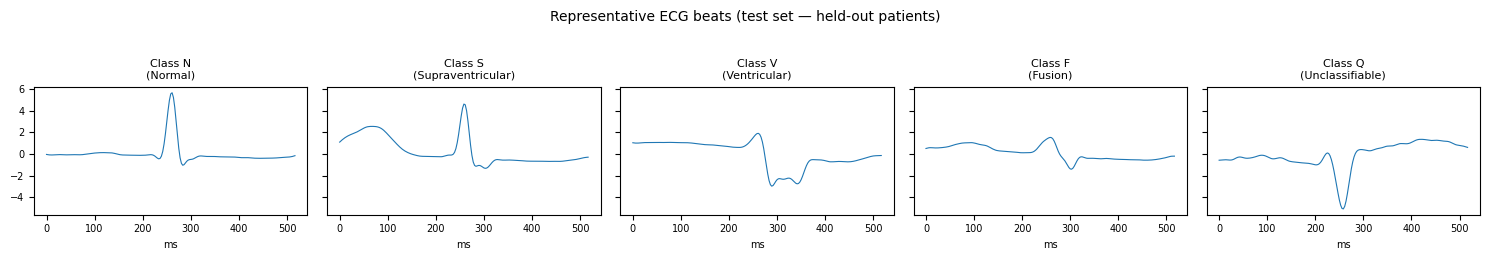

[01:45:44] Fig saved: beat_samples.png


In [5]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=360, order=4):
    """Butterworth bandpass filter to remove baseline wander and high-frequency noise."""
    nyq = 0.5 * fs
    b, a = sp_signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return sp_signal.filtfilt(b, a, signal)

print('Applying bandpass filter (0.5–40 Hz) ...')
X_filt = np.array([bandpass_filter(x) for x in tqdm(X_raw)], dtype=np.float32)

# ── FIX 1 (CRITICAL): Patient-level partition masks ───────────────────────
# Each beat is assigned to train / tuning / test based solely on which record
# it came from.  No beat from a test or tuning record ever touches training.
train_mask  = np.isin(rec_strings, TRAIN_RECORDS)
tuning_mask = np.isin(rec_strings, TUNING_RECORDS)
test_mask   = np.isin(rec_strings, TEST_RECORDS)

X_train_raw  = X_filt[train_mask];   y_train_raw  = y_raw[train_mask]
X_tuning     = X_filt[tuning_mask];  y_tuning     = y_raw[tuning_mask]
X_test       = X_filt[test_mask];    y_test        = y_raw[test_mask]

print(f'\nPatient-level partition sizes:')
print(f'  Train  : {X_train_raw.shape[0]:>6,} beats')
print(f'  Tuning : {X_tuning.shape[0]:>6,} beats  (threshold / hyperparam selection)')
print(f'  Test   : {X_test.shape[0]:>6,} beats  (held out — final eval only)')
log(f'Patient-level split — train={X_train_raw.shape[0]:,} | tuning={X_tuning.shape[0]:,} | test={X_test.shape[0]:,}')

# ── FIX 4 (MEDIUM): Conservative rebalancing — cap synthetic fraction ──────
# The original TARGET_PER_CLASS=10_000 caused ~12x duplication of class F.
# We cap the oversampling ratio at 3x the original minority-class count to
# reduce synthetic noise while still addressing severe imbalance.
counts_before = Counter(y_train_raw)

# Oversampling: bring all minority classes up to 5× their real count,
# capped at the majority class size.  Focal Loss handles the remaining
# imbalance through the gradient signal — excessive oversampling (8×+)
# was shown to hurt generalisation in the previous runs.
MAX_SYNTH_RATIO  = 5

def _synth_cap(n):
    return MAX_SYNTH_RATIO

TARGET_PER_CLASS = max(counts_before.values())   # majority class size

over_targets = {
    cls: min(int(n * MAX_SYNTH_RATIO), TARGET_PER_CLASS)
    for cls, n in counts_before.items()
    if int(n * MAX_SYNTH_RATIO) > n
}
print('Oversampling targets (5× cap, Focal Loss handles residual imbalance):')
for cls, tgt in sorted(over_targets.items()):
    real = counts_before[cls]
    print(f'  Class {cls}: {real:,} real → {tgt:,} (×{tgt/real:.1f})')
# Down-sample majority classes to the adjusted target
under_targets = {
    cls: TARGET_PER_CLASS
    for cls, n in counts_before.items()
    if n > TARGET_PER_CLASS
}

X_bal, y_bal = X_train_raw, y_train_raw
if under_targets:
    from imblearn.under_sampling import RandomUnderSampler
    rus = RandomUnderSampler(sampling_strategy=under_targets, random_state=SEED)
    X_bal, y_bal = rus.fit_resample(X_bal, y_bal)

# Track which samples are real (for representative dataset in TFLite, Fix 7)
n_real_after_under = len(y_bal)

counts_after_under = Counter(y_bal)
actual_over = {
    cls: min(int(counts_before[cls] * MAX_SYNTH_RATIO), TARGET_PER_CLASS)
    for cls, n in counts_after_under.items()
    if n < min(int(counts_before[cls] * MAX_SYNTH_RATIO), TARGET_PER_CLASS)
}
if actual_over:
    from imblearn.over_sampling import RandomOverSampler
    ros = RandomOverSampler(sampling_strategy=actual_over, random_state=SEED)
    X_train, y_train = ros.fit_resample(X_bal, y_bal)
else:
    X_train, y_train = X_bal, y_bal

# Record how many samples are real (pre-oversampling) for later use
n_real_train = n_real_after_under   # all samples up to this index are real

X_train_dl  = X_train.reshape(-1, WINDOW, 1)
X_tuning_dl = X_tuning.reshape(-1, WINDOW, 1)
X_test_dl   = X_test.reshape(-1, WINDOW, 1)

print(f'\nAfter rebalancing:')
print(f'  Train  : {X_train.shape[0]:,} beats | real={n_real_train:,} | synthetic={X_train.shape[0]-n_real_train:,}')
print(f'  Train class counts: {dict(Counter(y_train))}')
print(f'  Oversampling cap: {MAX_SYNTH_RATIO}x per minority class')
log(f'Split/rebalance done — train {X_train.shape[0]:,} | tuning {X_tuning.shape[0]:,} | test {X_test.shape[0]:,}')

# ── Plot sample beats per class ──────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(15, 2.5), sharey=True)
t = np.arange(WINDOW) / FS * 1000
for cls_id, ax in enumerate(axes):
    candidates = np.where(y_test == cls_id)[0]
    if len(candidates) == 0:
        ax.set_title(f'Class {CLASS_NAMES[cls_id]}\n(no samples)', fontsize=8)
        ax.axis('off')
        continue
    idx = candidates[0]
    ax.plot(t, X_test[idx], lw=0.8)
    ax.set_title(f'Class {CLASS_NAMES[cls_id]}\n({CLASS_LABELS[cls_id]})', fontsize=8)
    ax.set_xlabel('ms', fontsize=7)
    ax.tick_params(labelsize=7)
plt.suptitle('Representative ECG beats (test set — held-out patients)', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(fpath('beat_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
log('Fig saved: beat_samples.png')


## Section 4 — ECG Feature Engineering (for XGBoost branch)

In [6]:
def extract_features(beat, fs=FS):
    """Extract 20 interpretable ECG features from a single beat segment."""
    f = {}
    # Time-domain statistics
    f['mean']      = np.mean(beat)
    f['std']       = np.std(beat)
    f['max']       = np.max(beat)
    f['min']       = np.min(beat)
    f['rms']       = np.sqrt(np.mean(beat**2))
    f['skew']      = float(pd.Series(beat).skew())
    f['kurtosis']  = float(pd.Series(beat).kurtosis())
    f['zcr']       = ((beat[:-1] * beat[1:]) < 0).sum()  # zero-crossing rate
    f['energy']    = np.sum(beat**2)
    f['p2p']       = np.max(beat) - np.min(beat)         # peak-to-peak amplitude

    # Frequency-domain (Welch PSD)
    freqs, psd = sp_signal.welch(beat, fs=fs, nperseg=min(64, len(beat)))
    bands = [(0.5, 4), (4, 8), (8, 15), (15, 30), (30, 40)]
    for i, (lo, hi) in enumerate(bands):
        mask = (freqs >= lo) & (freqs <= hi)
        f[f'psd_b{i}'] = np.trapz(psd[mask], freqs[mask]) if mask.any() else 0.0

    # Morphology: R-peak position (max in centre window)
    mid = len(beat) // 2
    r_win = beat[mid-20:mid+20]
    f['r_amplitude']  = np.max(r_win) if len(r_win) > 0 else 0.0
    f['r_rel_pos']    = (np.argmax(r_win) - 20) / 40.0
    f['q_amplitude']  = beat[mid-10] if mid > 10 else 0.0
    f['s_amplitude']  = beat[mid+10] if mid+10 < len(beat) else 0.0

    return list(f.values())

FEATURE_NAMES = [
    'mean','std','max','min','rms','skew','kurtosis','zcr','energy','p2p',
    'psd_b0','psd_b1','psd_b2','psd_b3','psd_b4',
    'r_amplitude','r_rel_pos','q_amplitude','s_amplitude'  # FIX 8: was missing s_amplitude
]
# FIX 8: Sanity-check that names and feature vector lengths agree
_n_feat_check = len(extract_features(np.zeros(WINDOW)))
assert len(FEATURE_NAMES) == _n_feat_check, (
    f'FEATURE_NAMES has {len(FEATURE_NAMES)} entries but extract_features returns {_n_feat_check}'
)

print('Extracting features ...')
X_train_feat = np.array([extract_features(x) for x in tqdm(X_train)], dtype=np.float32)
X_test_feat  = np.array([extract_features(x) for x in tqdm(X_test)],  dtype=np.float32)

scaler = StandardScaler().fit(X_train_feat)
X_train_feat_s = scaler.transform(X_train_feat).astype(np.float32)
X_test_feat_s  = scaler.transform(X_test_feat).astype(np.float32)

print(f'Feature matrix: {X_train_feat_s.shape[1]} features per beat')

Extracting features ...


100%|██████████| 16284/16284 [00:22<00:00, 736.97it/s]


Feature matrix: 19 features per beat


## Section 5 — Base Learner Training

In [7]:
# ──────────────────────────────────────────────────────────────────────────
# FAST COMPLETE RASE-ECG BASE LEARNERS
# ──────────────────────────────────────────────────────────────────────────
# This cell replaces the slow CNN/self-attention configuration with a faster
# complete setup. It still trains CNN, BiGRU, Transformer-lite, and XGBoost,
# but uses safer defaults for Colab and CPU fallback.

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import xgboost as xgb
import time

# ──────────────────────────────────────────────────────────────────────────
# Runtime-aware precision policy
# ──────────────────────────────────────────────────────────────────────────
from tensorflow.keras import mixed_precision

GPU_AVAILABLE = len(tf.config.list_physical_devices('GPU')) > 0
if GPU_AVAILABLE:
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision enabled: mixed_float16')
else:
    mixed_precision.set_global_policy('float32')
    print('Mixed precision disabled: CPU runtime detected; using float32')

try:
    tf.config.optimizer.set_jit(False)  # safer for Keras 3 custom loss and Colab variability
except Exception:
    pass

# ──────────────────────────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────────────────────────
N_CLASSES = 5

# Fast complete defaults. Increase EPOCHS to 40 only after confirming that one
# epoch runs in seconds rather than minutes.
FAST_COMPLETE_MODE = True
EPOCHS = 12 if FAST_COMPLETE_MODE else 40
BATCH  = 2048 if FAST_COMPLETE_MODE else 1024

print(f'FAST_COMPLETE_MODE = {FAST_COMPLETE_MODE}')
print(f'EPOCHS={EPOCHS} | BATCH={BATCH} | GPU_AVAILABLE={GPU_AVAILABLE}')

# ──────────────────────────────────────────────────────────────────────────
# PROPER VALIDATION SPLIT
# IMPORTANT: no validation_split inside model.fit()
# ──────────────────────────────────────────────────────────────────────────
y_train_int = y_train.astype(int)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_dl, y_train_int,
    test_size=0.15, stratify=y_train_int, random_state=SEED
)
print(f'Validation split — train: {len(y_tr):,} | val: {len(y_val):,}')
print(f'Val class distribution: {dict(zip(*np.unique(y_val, return_counts=True)))}')

# ──────────────────────────────────────────────────────────────────────────
# tf.data pipeline for faster feeding
# ──────────────────────────────────────────────────────────────────────────
def make_ds(X, y=None, batch=BATCH, shuffle=False):
    X = X.astype(np.float32, copy=False)
    if y is None:
        ds = tf.data.Dataset.from_tensor_slices(X)
    else:
        y = y.astype(np.int32, copy=False)
        ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(min(len(X), 20000), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_tr, y_tr, shuffle=True)
val_ds   = make_ds(X_val, y_val, shuffle=False)

# ──────────────────────────────────────────────────────────────────────────
# Focal Loss
# ──────────────────────────────────────────────────────────────────────────
class SparseFocalLoss(keras.losses.Loss):
    """Multi-class focal loss for sparse integer labels."""
    def __init__(self, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred   = tf.cast(y_pred, tf.float32)
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_i = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_onehot = tf.one_hot(y_true_i, depth=N_CLASSES, dtype=tf.float32)
        p_t      = tf.reduce_sum(y_onehot * y_pred, axis=-1)
        focal_w  = tf.pow(1.0 - p_t, self.gamma)
        ce       = -tf.math.log(p_t)
        return tf.reduce_mean(focal_w * ce)

    def get_config(self):
        return {**super().get_config(), 'gamma': self.gamma}

_focal_loss = SparseFocalLoss(gamma=2.0, name='sparse_focal_loss')
print(f'Focal loss ready: {_focal_loss.name} (gamma={_focal_loss.gamma})')

def compile_and_fit(model, name):
    optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss=_focal_loss, metrics=['accuracy'])

    patience = 3 if FAST_COMPLETE_MODE else 6
    ES = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1)
    RLROP = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(2, patience-1), min_lr=1e-6, verbose=1)

    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[ES, RLROP], verbose=1)
    elapsed = time.time() - t0

    print(f'\n{name} trained successfully')
    print(f'Parameters : {model.count_params():,}')
    print(f'Time       : {elapsed:.1f}s')
    return model, history, elapsed

# ──────────────────────────────────────────────────────────────────────────
# Lightweight building blocks
# ──────────────────────────────────────────────────────────────────────────
def residual_block(x, filters, kernel=3, dropout=0.0):
    shortcut = x
    x = layers.Conv1D(filters, kernel, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    if dropout > 0:
        x = layers.SpatialDropout1D(dropout)(x)
    x = layers.Conv1D(filters, kernel, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    return layers.Activation('swish')(x)

# ──────────────────────────────────────────────────────────────────────────
# CNN — fast residual CNN, no self-attention by default
# ──────────────────────────────────────────────────────────────────────────
def build_cnn():
    inp = keras.Input(shape=(WINDOW, 1))
    x = layers.Conv1D(48, 7, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = residual_block(x, 48, dropout=0.05)
    x = layers.MaxPool1D(2)(x)
    x = residual_block(x, 96, dropout=0.08)
    x = layers.MaxPool1D(2)(x)
    x = residual_block(x, 128, dropout=0.10)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(96, activation='swish')(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(48, activation='swish')(x)
    x = layers.Dropout(0.20)(x)
    out = layers.Dense(N_CLASSES, activation='softmax', dtype='float32')(x)
    return Model(inp, out, name='CNN_FastResidual')

# ──────────────────────────────────────────────────────────────────────────
# BiGRU — compact recurrent learner
# ──────────────────────────────────────────────────────────────────────────
def build_gru():
    inp = keras.Input(shape=(WINDOW, 1))
    x = layers.Conv1D(32, 5, padding='same', activation='swish')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)
    x = layers.Bidirectional(layers.GRU(32, return_sequences=True))(x)
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(48, activation='swish')(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(N_CLASSES, activation='softmax', dtype='float32')(x)
    return Model(inp, out, name='BiGRU_Compact')

# ──────────────────────────────────────────────────────────────────────────
# Transformer-lite — compact attention branch
# ──────────────────────────────────────────────────────────────────────────
def transformer_encoder(x, embed_dim, num_heads, ff_dim, dropout=0.15):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    ff = layers.Dense(ff_dim, activation='swish')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(embed_dim)(ff)
    x = layers.Add()([x, ff])
    return layers.LayerNormalization(epsilon=1e-6)(x)

def build_transformer():
    inp = keras.Input(shape=(WINDOW, 1))
    x = layers.Conv1D(64, 7, strides=2, padding='same', activation='swish')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(96, 5, strides=2, padding='same', activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = transformer_encoder(x, embed_dim=96, num_heads=4, ff_dim=128, dropout=0.15)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='swish')(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(N_CLASSES, activation='softmax', dtype='float32')(x)
    return Model(inp, out, name='Transformer_Lite')

# ──────────────────────────────────────────────────────────────────────────
# TRAIN MODELS
# ──────────────────────────────────────────────────────────────────────────
print('\nTraining CNN...\n')
cnn_model, cnn_hist, cnn_time = compile_and_fit(build_cnn(), 'CNN')

print('\nTraining BiGRU...\n')
gru_model, gru_hist, gru_time = compile_and_fit(build_gru(), 'BiGRU')

print('\nTraining Transformer-lite...\n')
tfm_model, tfm_hist, tfm_time = compile_and_fit(build_transformer(), 'Transformer')

# ──────────────────────────────────────────────────────────────────────────
# XGBOOST
# ──────────────────────────────────────────────────────────────────────────
print('\nTraining XGBoost...\n')
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=180 if FAST_COMPLETE_MODE else 300,
    max_depth=6 if FAST_COMPLETE_MODE else 8,
    learning_rate=0.05 if FAST_COMPLETE_MODE else 0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist'
)

_X_xgb_tr, _X_xgb_val, _y_xgb_tr, _y_xgb_val = train_test_split(
    X_train_feat_s, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)
xgb_model.fit(_X_xgb_tr, _y_xgb_tr, eval_set=[(_X_xgb_val, _y_xgb_val)], verbose=False)
xgb_time = time.time() - t0

print('\nXGBoost trained successfully')
print(f'Time : {xgb_time:.1f}s')

print('\nAll base learners trained successfully.\n')
print(f'CNN Time          : {cnn_time:.1f}s')
print(f'BiGRU Time        : {gru_time:.1f}s')
print(f'Transformer Time  : {tfm_time:.1f}s')
print(f'XGBoost Time      : {xgb_time:.1f}s')

log(f'Base learners trained | CNN={cnn_time:.1f}s | BiGRU={gru_time:.1f}s | Transformer={tfm_time:.1f}s | XGB={xgb_time:.1f}s')


Mixed precision enabled: mixed_float16
FAST_COMPLETE_MODE = True
EPOCHS=12 | BATCH=2048 | GPU_AVAILABLE=True
Validation split — train: 116,583 | val: 20,574
Val class distribution: {np.int64(0): np.int64(9605), np.int64(1): np.int64(1773), np.int64(2): np.int64(4127), np.int64(3): np.int64(588), np.int64(4): np.int64(4481)}
Focal loss ready: sparse_focal_loss (gamma=2.0)

Training CNN...

Epoch 1/12
57/57 ━━━━━━━━━━━━━━━━━━━━ 63s 707ms/step - accuracy: 0.8160 - loss: 0.3079 - val_accuracy: 0.5518 - val_loss: 0.9440 - learning_rate: 0.0010
Epoch 2/12
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9214 - loss: 0.1059 - val_accuracy: 0.3676 - val_loss: 0.9743 - learning_rate: 0.0010
Epoch 3/12
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9383 - loss: 0.0750 - val_accuracy: 0.4228 - val_loss: 0.8745 - learning_rate: 0.0010
Epoch 4/12
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9481 - loss: 0.0600 - val_accuracy: 0.4355 - val_loss: 0.8978 - learning_rate: 0.0010
Ep

## Section 6 — Stacking with Calibrated Meta-Learner

In [8]:
# ── FIX 3 (HIGH): Out-of-fold (OOF) stacking ─────────────────────────────
# Base learners predict on the TUNING partition (held-out patients they never
# saw during training) → unbiased meta-features with no extra retraining cost.

print('Generating meta-features using held-out tuning partition ...')

def get_proba_dl(model, X):   return model.predict(X, verbose=0)
def get_proba_xgb(model, X):  return model.predict_proba(X)

# ── Extract features for tuning partition (XGBoost branch) ────────────────
print('Extracting features for tuning set ...')
X_tuning_feat   = np.array([extract_features(x) for x in tqdm(X_tuning)], dtype=np.float32)
X_tuning_feat_s = scaler.transform(X_tuning_feat).astype(np.float32)

# ── Meta-features ─────────────────────────────────────────────────────────
meta_train = np.hstack([
    get_proba_dl(cnn_model,  X_tuning_dl),
    get_proba_dl(gru_model,  X_tuning_dl),
    get_proba_dl(tfm_model,  X_tuning_dl),
    get_proba_xgb(xgb_model, X_tuning_feat_s),
])
y_meta_train = y_tuning

meta_test = np.hstack([
    get_proba_dl(cnn_model,  X_test_dl),
    get_proba_dl(gru_model,  X_test_dl),
    get_proba_dl(tfm_model,  X_test_dl),
    get_proba_xgb(xgb_model, X_test_feat_s),
])
print(f'Meta-feature shape — train(tuning): {meta_train.shape}, test: {meta_test.shape}')

# ── Calibrated LR meta-learner ────────────────────────────────────────────
# The tuning partition may contain very few beats for rare classes (F, Q).
# We adapt cv and calibration method to the actual minority-class count so
# CalibratedClassifierCV never requests more folds than it has samples.
_class_counts   = np.unique(y_meta_train, return_counts=True)[1]
_min_cls_count  = int(_class_counts.min())
_cv             = min(5, max(2, _min_cls_count))   # clamp to [2, 5]
_cal_method     = 'sigmoid' if _min_cls_count < 10 else 'isotonic'
print(f'Minority class count: {_min_cls_count} → cv={_cv}, calibration method={_cal_method!r}')

base_meta = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, multi_class='multinomial')
meta_clf  = CalibratedClassifierCV(base_meta, method=_cal_method, cv=_cv)
meta_clf.fit(meta_train, y_meta_train)
print('Calibrated meta-learner fitted on tuning partition.')

# ── MLP meta-learner ──────────────────────────────────────────────────────
# Use an explicit stratified split instead of validation_split= so the
# validation slice is drawn correctly even with imbalanced tuning data.
from sklearn.model_selection import train_test_split as _tts2
_m_tr, _m_val, _ym_tr, _ym_val = _tts2(
    meta_train, y_meta_train,
    test_size=0.2, random_state=SEED, stratify=y_meta_train,
)

def build_mlp_meta():
    inp = keras.Input(shape=(meta_train.shape[1],))
    x   = layers.Dense(64, activation='relu')(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(N_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='MLP_meta')

ES_mlp   = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=0)
mlp_meta = build_mlp_meta()
mlp_meta.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp_meta.fit(
    _m_tr, _ym_tr,
    epochs=50, batch_size=128,
    validation_data=(_m_val, _ym_val),
    callbacks=[ES_mlp], verbose=0,
)
print('MLP meta-learner fitted.')

# ── Save all models ────────────────────────────────────────────────────────
cnn_model.save(mdl('model_cnn.keras'))
gru_model.save(mdl('model_gru.keras'))
tfm_model.save(mdl('model_transformer.keras'))
mlp_meta.save(mdl('model_mlp_meta.keras'))
import joblib
joblib.dump(xgb_model, mdl('model_xgb.joblib'))
joblib.dump(meta_clf,  mdl('model_meta_lr_calibrated.joblib'))
joblib.dump(scaler,    mdl('scaler_features.joblib'))
log('All models saved to Drive')

# ── Final predictions on TEST set ─────────────────────────────────────────
y_pred_proba = meta_clf.predict_proba(meta_test)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_conf       = np.max(y_pred_proba, axis=1)

# ── FIX 5 (CLINICAL): Clinical thresholds fixed on TUNING set ─────────────
# Thresholds are locked here, before the test set is ever inspected.
print('\nSelecting clinical thresholds on TUNING partition (FIX 5) ...')
tuning_pred_proba = meta_clf.predict_proba(meta_train)
tuning_pred       = np.argmax(tuning_pred_proba, axis=1)
tuning_conf       = np.max(tuning_pred_proba, axis=1)
tuning_correct    = (tuning_pred == y_meta_train).astype(float)

_nominal = {'Screening-oriented': 0.70, 'Balanced': 0.85, 'High-confidence': 0.95}
CLINICAL_THRESHOLDS = {}
print('Threshold validation on TUNING set:')
for mode, th in _nominal.items():
    mask = tuning_conf >= th
    if mask.sum() == 0:
        CLINICAL_THRESHOLDS[mode] = th
        print(f'  {mode:25s} th={th:.2f}  coverage= 0.0%  (no samples — threshold kept)')
        continue
    cov = mask.mean()
    err = 1.0 - tuning_correct[mask].mean()
    CLINICAL_THRESHOLDS[mode] = th
    print(f'  {mode:25s} th={th:.2f}  coverage={100*cov:5.1f}%  error={100*err:.2f}%')
log(f'Clinical thresholds fixed on tuning set: {CLINICAL_THRESHOLDS}')


Generating meta-features using held-out tuning partition ...
Extracting features for tuning set ...


100%|██████████| 14527/14527 [00:20<00:00, 722.75it/s]


Meta-feature shape — train(tuning): (14527, 20), test: (16284, 20)
Minority class count: 3 → cv=3, calibration method='sigmoid'
Calibrated meta-learner fitted on tuning partition.
MLP meta-learner fitted.
[01:53:59] All models saved to Drive

Selecting clinical thresholds on TUNING partition (FIX 5) ...
Threshold validation on TUNING set:
  Screening-oriented        th=0.70  coverage= 91.5%  error=1.84%
  Balanced                  th=0.85  coverage= 81.8%  error=0.96%
  High-confidence           th=0.95  coverage= 50.7%  error=0.68%
[01:53:59] Clinical thresholds fixed on tuning set: {'Screening-oriented': 0.7, 'Balanced': 0.85, 'High-confidence': 0.95}


## Section 7 — Standard Evaluation

=== RASE-ECG Ensemble — Classification Report ===
              precision    recall  f1-score   support

           N     0.9692    0.9888    0.9789     15132
           S     0.0000    0.0000    0.0000       355
           V     0.8924    0.7892    0.8377       778
           F     0.0000    0.0000    0.0000        15
           Q     0.0000    0.0000    0.0000         4

    accuracy                         0.9565     16284
   macro avg     0.3723    0.3556    0.3633     16284
weighted avg     0.9433    0.9565    0.9497     16284

Accuracy: 0.9565 | Macro-F1: 0.3633 | AUC-OvR: 0.5870


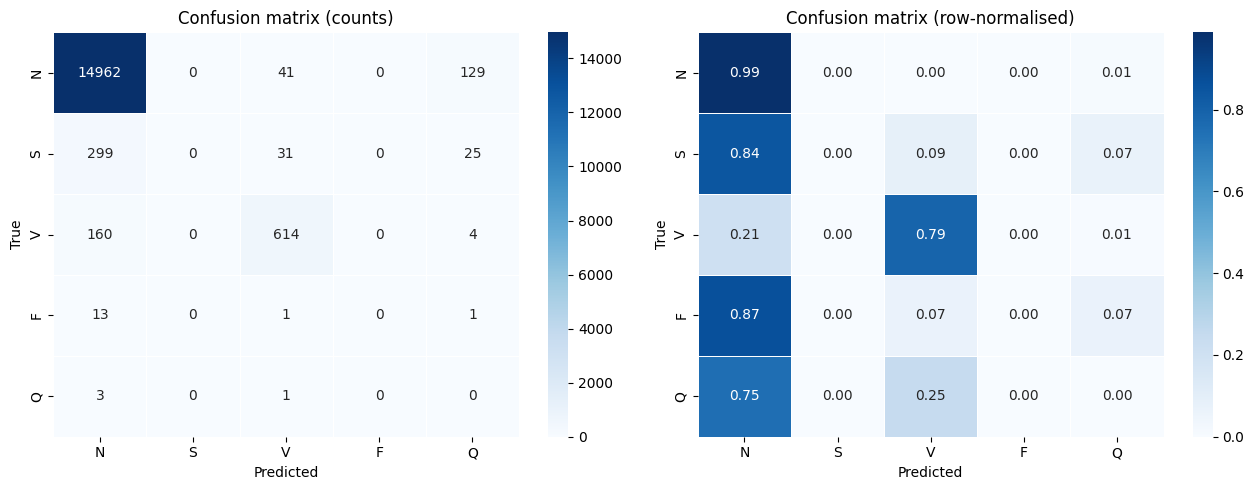

[01:54:09] Evaluation — Acc=0.9565 | Macro-F1=0.3633 | AUC=0.5870
[01:54:09] Fig saved: confusion_matrices.png

=== Model comparison: prediction + probabilistic quality ===
           Model  Accuracy  Macro-F1  AUC-OvR  Brier    NLL
RASE-ECG (stack)    0.9565    0.3633   0.5870 0.0774 0.2123
         XGBoost    0.8980    0.3170   0.7484 0.1691 0.3465
     Transformer    0.7389    0.3019   0.7599 0.3575 0.5924
             CNN    0.6357    0.1965   0.6963 0.5712 1.0986
             GRU    0.0480    0.0183   0.6340 1.0158 1.7843
[01:54:18] Table saved: model_comparison_reliability.csv


In [9]:
# ── Per-class metrics ─────────────────────────────────────────────────────
print('=== RASE-ECG Ensemble — Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
try:
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
except Exception:
    auc = float('nan')
print(f'Accuracy: {acc:.4f} | Macro-F1: {f1m:.4f} | AUC-OvR: {auc:.4f}')

cm = confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion matrix (counts)', 'Confusion matrix (row-normalised)'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.4, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(fpath('confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
log(f'Evaluation — Acc={acc:.4f} | Macro-F1={f1m:.4f} | AUC={auc:.4f}')
log('Fig saved: confusion_matrices.png')

# ── Per-model baseline comparison ────────────────────────────────────────
cnn_prob = get_proba_dl(cnn_model, X_test_dl)
gru_prob = get_proba_dl(gru_model, X_test_dl)
tfm_prob = get_proba_dl(tfm_model, X_test_dl)
xgb_prob = get_proba_xgb(xgb_model, X_test_feat_s)

models_eval = {
    'CNN':              (np.argmax(cnn_prob, 1), cnn_prob),
    'GRU':              (np.argmax(gru_prob, 1), gru_prob),
    'Transformer':      (np.argmax(tfm_prob, 1), tfm_prob),
    'XGBoost':          (xgb_model.predict(X_test_feat_s), xgb_prob),
    'RASE-ECG (stack)': (y_pred, y_pred_proba),
}

def multiclass_brier(y_true, probas, n_classes=N_CLASSES):
    y_onehot = np.eye(n_classes)[y_true]
    return np.mean(np.sum((y_onehot - probas) ** 2, axis=1))

rows = []
for name, (preds, probas) in models_eval.items():
    try:
        auc_model = roc_auc_score(y_test, probas, multi_class='ovr', average='macro')
    except Exception:
        auc_model = np.nan
    try:
        nll_model = log_loss(y_test, probas, labels=np.arange(N_CLASSES))
    except Exception:
        nll_model = np.nan
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Macro-F1': f1_score(y_test, preds, average='macro'),
        'AUC-OvR': auc_model,
        'Brier': multiclass_brier(y_test, probas),
        'NLL': nll_model,
    })

df_cmp = pd.DataFrame(rows).sort_values(['Macro-F1', 'Accuracy'], ascending=False)
print('\n=== Model comparison: prediction + probabilistic quality ===')
print(df_cmp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df_cmp.to_csv(tbl('model_comparison_reliability.csv'), index=False)
log('Table saved: model_comparison_reliability.csv')


In [10]:
# ── FIX 4 (MEDIUM): Bootstrap 95% confidence intervals ───────────────────
# Point estimates alone are insufficient for clinical reporting.
# We bootstrap F1 and AUC per class with n=1000 resamples.
from sklearn.metrics import f1_score as _f1, roc_auc_score as _auc

N_BOOT = 1000
np.random.seed(SEED)
boot_f1   = np.zeros((N_BOOT, N_CLASSES))
boot_auc  = np.zeros((N_BOOT, N_CLASSES))
n_test    = len(y_test)

for b in range(N_BOOT):
    idx_b = np.random.choice(n_test, n_test, replace=True)
    y_b   = y_test[idx_b]
    p_b   = y_pred_proba[idx_b]
    pr_b  = np.argmax(p_b, axis=1)
    boot_f1[b]  = _f1(y_b, pr_b, average=None, labels=np.arange(N_CLASSES), zero_division=0)
    for c in range(N_CLASSES):
        if len(np.unique(y_b)) > 1 and (y_b == c).any():
            try:
                boot_auc[b, c] = _auc((y_b == c).astype(int), p_b[:, c])
            except Exception:
                boot_auc[b, c] = np.nan
        else:
            boot_auc[b, c] = np.nan

ci_lo_f1  = np.nanpercentile(boot_f1,  2.5,  axis=0)
ci_hi_f1  = np.nanpercentile(boot_f1, 97.5,  axis=0)
ci_lo_auc = np.nanpercentile(boot_auc,  2.5,  axis=0)
ci_hi_auc = np.nanpercentile(boot_auc, 97.5,  axis=0)

print('=== Per-class metrics with 95% bootstrap CIs (n=1000) ===')
print(f'{"Class":<6} {"F1":>7} {"[95% CI]":>18}   {"AUC":>7} {"[95% CI]":>18}')
print('-' * 62)
for c in range(N_CLASSES):
    pt_f1  = _f1(y_test, y_pred, average=None, labels=np.arange(N_CLASSES), zero_division=0)[c]
    try:
        pt_auc = _auc((y_test == c).astype(int), y_pred_proba[:, c])
    except Exception:
        pt_auc = float('nan')
    print(f'{CLASS_NAMES[c]:<6} {pt_f1:>7.4f} [{ci_lo_f1[c]:.4f}, {ci_hi_f1[c]:.4f}]'
          f'   {pt_auc:>7.4f} [{ci_lo_auc[c]:.4f}, {ci_hi_auc[c]:.4f}]')

df_ci = pd.DataFrame({
    'Class':    CLASS_NAMES,
    'F1':       [_f1(y_test, y_pred, average=None, labels=np.arange(N_CLASSES), zero_division=0)[c] for c in range(N_CLASSES)],
    'F1_CI_lo': ci_lo_f1,
    'F1_CI_hi': ci_hi_f1,
    'AUC':      [(_auc((y_test==c).astype(int), y_pred_proba[:,c]) if (y_test==c).any() else np.nan) for c in range(N_CLASSES)],
    'AUC_CI_lo': ci_lo_auc,
    'AUC_CI_hi': ci_hi_auc,
})
df_ci.to_csv(tbl('bootstrap_ci.csv'), index=False)
log('Bootstrap CIs saved → Tables/bootstrap_ci.csv')


=== Per-class metrics with 95% bootstrap CIs (n=1000) ===
Class       F1           [95% CI]       AUC           [95% CI]
--------------------------------------------------------------
N       0.9789 [0.9772, 0.9805]    0.8832 [0.8686, 0.8980]
S       0.0000 [0.0000, 0.0000]    0.4704 [0.4340, 0.5074]
V       0.8377 [0.8173, 0.8564]    0.9941 [0.9922, 0.9957]
F       0.0000 [0.0000, 0.0000]    0.4421 [0.2070, 0.6890]
Q       0.0000 [0.0000, 0.0000]    0.1450 [0.0886, 0.1692]
[01:55:11] Bootstrap CIs saved → Tables/bootstrap_ci.csv


## Section 8 — Reliability Layer
### 8A. Calibration curves & Expected Calibration Error (ECE)
### 8B. Confidence-risk curves
### 8C. Selective prediction / abstention

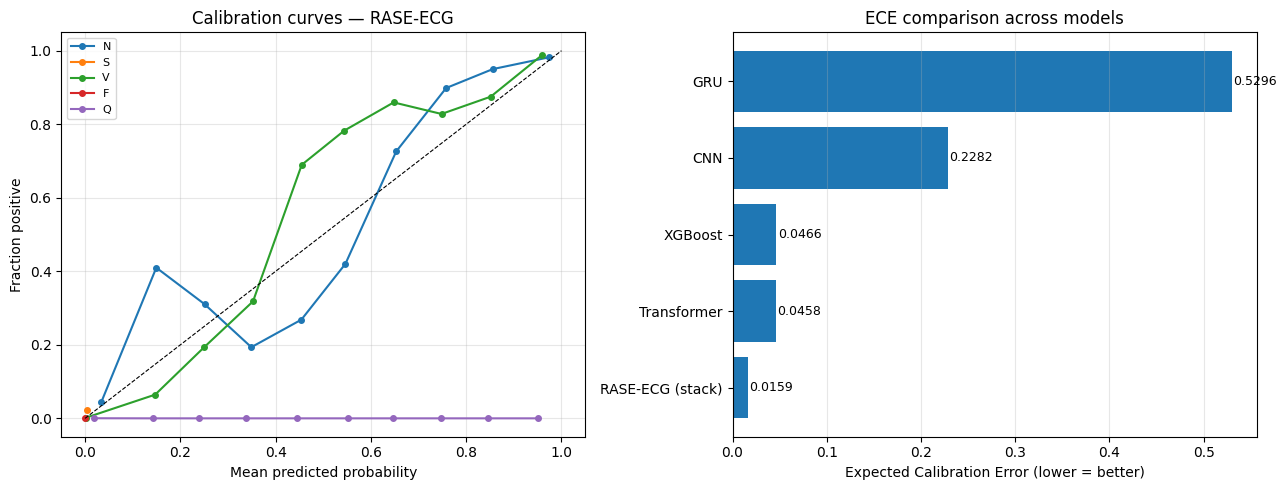


RASE-ECG ECE: 0.0159
[01:55:53] Calibration — RASE-ECG ECE=0.0159
[01:55:53] Fig saved: calibration.png | Table saved: ece_comparison.csv


In [11]:
# ── 8A. Calibration curves and Expected Calibration Error ────────────────
def compute_ece(y_true, y_prob, n_bins=15):
    """Expected Calibration Error using equal-width confidence bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    conf = np.max(y_prob, axis=1)
    pred = np.argmax(y_prob, axis=1)
    correct_local = (pred == y_true).astype(float)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf >= lo) & (conf < hi if hi < 1 else conf <= hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(y_true)) * abs(correct_local[mask].mean() - conf[mask].mean())
    return float(ece)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for cls_id in range(N_CLASSES):
    y_bin = (y_test == cls_id).astype(int)
    prob_cls = y_pred_proba[:, cls_id]
    frac_pos, mean_pred = calibration_curve(y_bin, prob_cls, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, 'o-', label=CLASS_NAMES[cls_id], markersize=4)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction positive')
ax.set_title('Calibration curves — RASE-ECG')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ECE bar chart for all models
ece_vals = {name: compute_ece(y_test, probas) for name, (_, probas) in models_eval.items()}
names_sorted = sorted(ece_vals, key=ece_vals.get)
ax2 = axes[1]
bars = ax2.barh(names_sorted, [ece_vals[n] for n in names_sorted])
for bar, v in zip(bars, [ece_vals[n] for n in names_sorted]):
    ax2.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
ax2.set_xlabel('Expected Calibration Error (lower = better)')
ax2.set_title('ECE comparison across models')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(fpath('calibration.png'), dpi=150, bbox_inches='tight')
plt.show()

df_ece = pd.DataFrame({'Model': list(ece_vals.keys()), 'ECE': list(ece_vals.values())}).sort_values('ECE')
df_ece.to_csv(tbl('ece_comparison.csv'), index=False)
ece_stack = ece_vals['RASE-ECG (stack)']
print(f'\nRASE-ECG ECE: {ece_stack:.4f}')
log(f'Calibration — RASE-ECG ECE={ece_stack:.4f}')
log('Fig saved: calibration.png | Table saved: ece_comparison.csv')


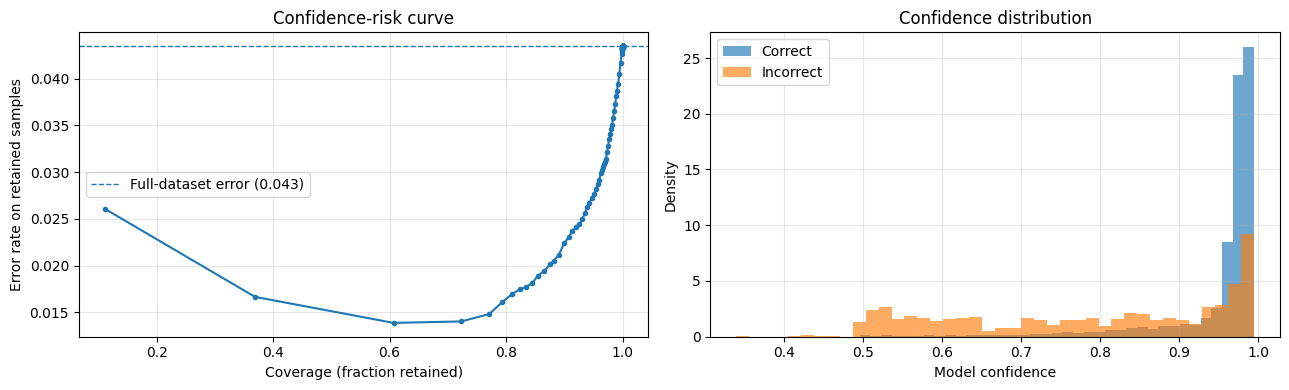


=== Selective prediction summary ===
 Confidence threshold  Coverage  Abstention rate  Retained accuracy  Retained error  Mean entropy retained
               0.5000    0.9986           0.0014             0.9573          0.0427                 0.1932
               0.7000    0.9625           0.0375             0.9701          0.0299                 0.1738
               0.8000    0.9260           0.0740             0.9756          0.0244                 0.1575
               0.9000    0.8448           0.1552             0.9819          0.0181                 0.1304
               0.9500    0.7711           0.2289             0.9852          0.0148                 0.1164
               0.9900    0.1107           0.8893             0.9739          0.0261                 0.0565
[01:56:04] Fig saved: confidence_risk.png | Table saved: selective_prediction_table.csv


In [12]:
# ── 8B. Confidence-risk, entropy, and abstention analysis ────────────────
thresholds = np.linspace(0.0, 0.99, 100)
coverage, error_rate, abstentions = [], [], []
correct = (y_pred == y_test).astype(float)

for th in thresholds:
    mask = y_conf >= th
    if mask.sum() == 0:
        continue
    coverage.append(mask.mean())
    error_rate.append(1.0 - correct[mask].mean())
    abstentions.append(1.0 - mask.mean())

# Entropy: higher value = more uncertain probability distribution
pred_entropy = -np.sum(y_pred_proba * np.log(y_pred_proba + 1e-12), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(coverage, error_rate, 'o-', markersize=3, lw=1.5)
ax.axhline(1 - acc, ls='--', lw=1, label=f'Full-dataset error ({1-acc:.3f})')
ax.set_xlabel('Coverage (fraction retained)')
ax.set_ylabel('Error rate on retained samples')
ax.set_title('Confidence-risk curve')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.hist(y_conf[y_pred == y_test], bins=40, alpha=0.65, label='Correct', density=True)
ax2.hist(y_conf[y_pred != y_test], bins=40, alpha=0.65, label='Incorrect', density=True)
ax2.set_xlabel('Model confidence')
ax2.set_ylabel('Density')
ax2.set_title('Confidence distribution')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fpath('confidence_risk.png'), dpi=150, bbox_inches='tight')
plt.show()

# Selective-prediction operating table
sel_rows = []
for th in [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]:
    mask = y_conf >= th
    if mask.sum() == 0:
        continue
    sel_rows.append({
        'Confidence threshold': th,
        'Coverage': mask.mean(),
        'Abstention rate': 1.0 - mask.mean(),
        'Retained accuracy': correct[mask].mean(),
        'Retained error': 1.0 - correct[mask].mean(),
        'Mean entropy retained': pred_entropy[mask].mean(),
    })

df_selective = pd.DataFrame(sel_rows)
print('\n=== Selective prediction summary ===')
print(df_selective.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df_selective.to_csv(tbl('selective_prediction_table.csv'), index=False)
log('Fig saved: confidence_risk.png | Table saved: selective_prediction_table.csv')


### 8C. Clinical operating modes and uncertainty separation

This section translates reliability into decision-support modes: high-sensitivity screening, balanced operation, and high-confidence automated support.

=== Reliability-aware clinical operating modes ===
              Mode  Threshold  Coverage  Retained accuracy  Abstention rate  Mean entropy
Screening-oriented     0.7000    0.9625             0.9701           0.0375        0.1738
          Balanced     0.8500    0.8906             0.9788           0.1094        0.1443
   High-confidence     0.9500    0.7711             0.9852           0.2289        0.1164


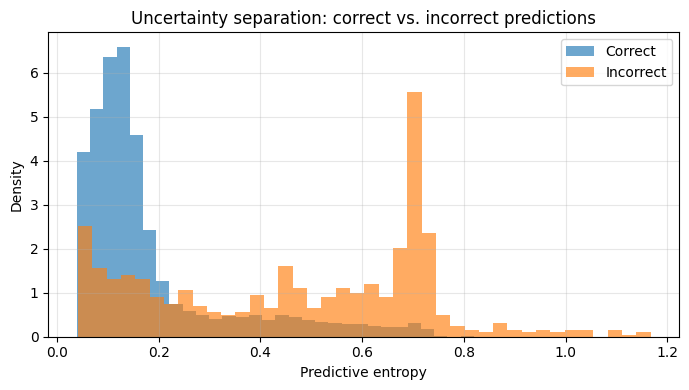

[01:56:17] Fig saved: entropy_error_separation.png | Table saved: clinical_operating_modes.csv


In [13]:
# ── Clinical operating modes and entropy-error separation ───────────────
# FIX 5 (CLINICAL): Use thresholds fixed on the TUNING set (not the test set)
operating_modes = CLINICAL_THRESHOLDS
mode_rows = []
for mode, th in operating_modes.items():
    mask = y_conf >= th
    if mask.sum() == 0:
        mode_rows.append({'Mode': mode, 'Threshold': th, 'Coverage': 0, 'Retained accuracy': np.nan,
                          'Abstention rate': 1.0, 'Mean entropy': np.nan})
        continue
    mode_rows.append({
        'Mode': mode,
        'Threshold': th,
        'Coverage': mask.mean(),
        'Retained accuracy': correct[mask].mean(),
        'Abstention rate': 1 - mask.mean(),
        'Mean entropy': pred_entropy[mask].mean(),
    })

df_modes = pd.DataFrame(mode_rows)
print('=== Reliability-aware clinical operating modes ===')
print(df_modes.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df_modes.to_csv(tbl('clinical_operating_modes.csv'), index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pred_entropy[y_pred == y_test], bins=40, alpha=0.65, label='Correct', density=True)
ax.hist(pred_entropy[y_pred != y_test], bins=40, alpha=0.65, label='Incorrect', density=True)
ax.set_xlabel('Predictive entropy')
ax.set_ylabel('Density')
ax.set_title('Uncertainty separation: correct vs. incorrect predictions')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fpath('entropy_error_separation.png'), dpi=150, bbox_inches='tight')
plt.show()
log('Fig saved: entropy_error_separation.png | Table saved: clinical_operating_modes.csv')


## Section 9 — Explainability Layer
### 9A. SHAP for meta-learner (why did the ensemble decide this?)
### 9B. Grad-CAM saliency on CNN branch (which ECG segment mattered?)

  0%|          | 0/300 [00:00<?, ?it/s]

SHAP values ready: 5 classes, each (300, 20)


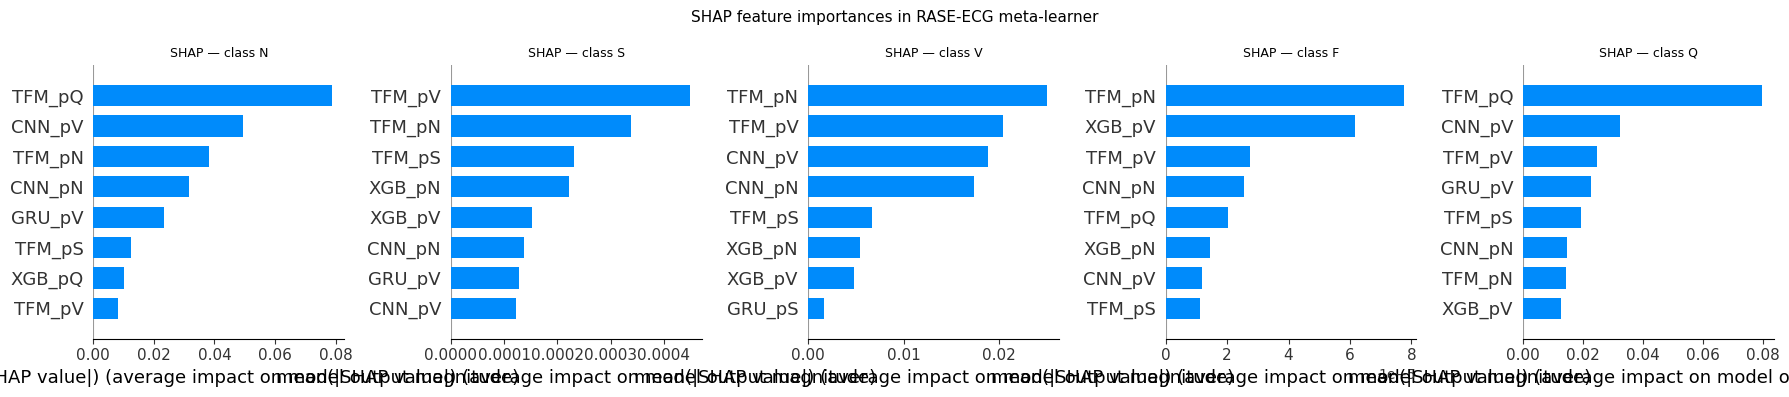

[01:56:42] Fig saved: shap_meta.png

=== Mean |SHAP| contribution per base learner ===
  Class N: CNN=0.0175 | GRU=0.0068 | Transformer-lite=0.0277 | XGBoost=0.0050
  Class S: CNN=0.0001 | GRU=0.0000 | Transformer-lite=0.0002 | XGBoost=0.0001
  Class V: CNN=0.0077 | GRU=0.0010 | Transformer-lite=0.0108 | XGBoost=0.0026
  Class F: CNN=0.0000 | GRU=0.0000 | Transformer-lite=0.0000 | XGBoost=0.0000
  Class Q: CNN=0.0108 | GRU=0.0067 | Transformer-lite=0.0277 | XGBoost=0.0049
[01:56:42] Table saved: shap_branch_contributions.csv


In [14]:
# ── 9A. SHAP on meta-features ────────────────────────────────────────────
# The 20 meta-features are: [CNN_N, CNN_S, CNN_V, CNN_F, CNN_Q,
#                             GRU_N, ..., Transformer_N, ..., XGB_N, ...]
META_FEATURE_NAMES = (
    [f'CNN_p{c}'  for c in CLASS_NAMES] +
    [f'GRU_p{c}'  for c in CLASS_NAMES] +
    [f'TFM_p{c}'  for c in CLASS_NAMES] +
    [f'XGB_p{c}'  for c in CLASS_NAMES]
)

# kmeans(50) summarises background → faster and no 200-sample warning
background = shap.kmeans(meta_train, 50)
explainer  = shap.KernelExplainer(meta_clf.predict_proba, background)

# Explain 300 random test beats
# FIX 9 (LOW): Reset RNG immediately before sampling so SHAP results are
# reproducible regardless of prior stochastic operations in the notebook.
np.random.seed(SEED)
n_explain = min(300, len(meta_test))
idx_sample = np.random.choice(len(meta_test), n_explain, replace=False)
X_explain  = meta_test[idx_sample]
shap_raw   = explainer.shap_values(X_explain, nsamples=100)

# ── Normalise output: API differs across SHAP versions ───────────────────
# v0.41+  → ndarray  (n_samples, n_features, n_classes)
# older   → list of  (n_samples, n_features),  one per class
if isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
    sv_list = [shap_raw[:, :, c] for c in range(N_CLASSES)]
elif isinstance(shap_raw, list):
    sv_list = shap_raw
else:
    sv_list = [shap_raw] * N_CLASSES

# Sanity check: every element must match X_explain
for c, sv in enumerate(sv_list):
    assert sv.shape == X_explain.shape, (
        f'Class {c}: SHAP shape {sv.shape} != data shape {X_explain.shape}'
    )
print(f'SHAP values ready: {len(sv_list)} classes, each {sv_list[0].shape}')

# ── One bar-plot per class ────────────────────────────────────────────────
_fig, axes = plt.subplots(1, N_CLASSES, figsize=(18, 4))
for cls_id, ax in enumerate(axes):
    plt.sca(ax)
    shap.summary_plot(
        sv_list[cls_id],   # (300, 20)
        X_explain,         # (300, 20)
        feature_names=META_FEATURE_NAMES,
        plot_type='bar', show=False, max_display=8,
        plot_size=None
    )
    ax.set_title(f'SHAP — class {CLASS_NAMES[cls_id]}', fontsize=9)
plt.suptitle('SHAP feature importances in RASE-ECG meta-learner', fontsize=11)
plt.tight_layout()
plt.savefig(fpath('shap_meta.png'), dpi=150, bbox_inches='tight')
plt.show()
log('Fig saved: shap_meta.png')

# ── Mean |SHAP| per base learner branch ──────────────────────────────────
print('\n=== Mean |SHAP| contribution per base learner ===')
branch_names = ['CNN', 'GRU', 'Transformer-lite', 'XGBoost']
for cls_id in range(N_CLASSES):
    sv = np.abs(sv_list[cls_id])
    branch_imp = [sv[:, i*5:(i+1)*5].mean() for i in range(4)]
    print(f'  Class {CLASS_NAMES[cls_id]}: ' +
          ' | '.join(f'{b}={v:.4f}' for b, v in zip(branch_names, branch_imp)))

# Save branch-level explanation contribution table
shap_branch_rows = []
for cls_id in range(N_CLASSES):
    sv = np.abs(sv_list[cls_id])
    branch_imp = [sv[:, i*5:(i+1)*5].mean() for i in range(4)]
    for b, v in zip(branch_names, branch_imp):
        shap_branch_rows.append({'Class': CLASS_NAMES[cls_id], 'Branch': b, 'Mean_abs_SHAP': v})
pd.DataFrame(shap_branch_rows).to_csv(tbl('shap_branch_contributions.csv'), index=False)
log('Table saved: shap_branch_contributions.csv')


Grad-CAM target layer: conv1d_7


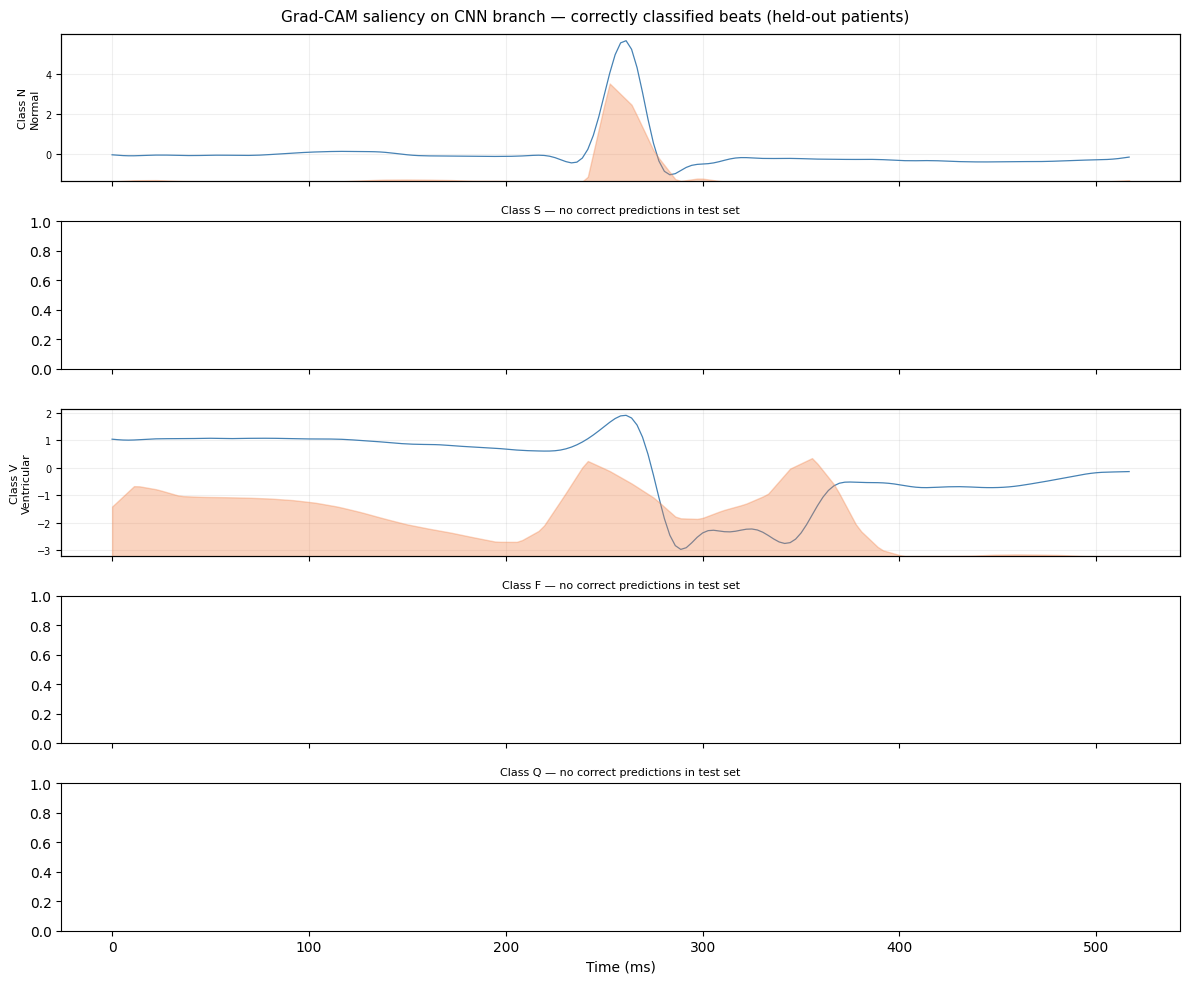

[01:56:55] Fig saved: gradcam_saliency.png

=== Inter-patient generalisation summary (FIX 6) ===
  Tuning patients: Acc=0.9577  Macro-F1=0.5502  AUC=0.9325
  Test   patients: Acc=0.9565  Macro-F1=0.3633  AUC=0.5870
[01:56:55] Inter-patient generalisation summary printed.


In [15]:
# ── 9B. Grad-CAM saliency on CNN ─────────────────────────────────────────
# FIX 7 (MEDIUM): Select the correct Conv1D layer for Grad-CAM.
# The optimized CNN no longer uses the slow self-attention block. Residual
# connections can still contain 1x1 Conv1D projections. Naively taking the
# "last Conv1D" may return a pointwise projection, which is uninformative.
# Instead, we explicitly target the last feature-extracting Conv1D
# with kernel_size > 1.

last_conv_layer = None
for layer in reversed(cnn_model.layers):
    # FIX 7: skip 1x1 dimension-matching projections (kernel_size == 1)
    if isinstance(layer, layers.Conv1D) and layer.kernel_size[0] > 1:
        last_conv_layer = layer.name
        break

assert last_conv_layer is not None, "No Conv1D with kernel > 1 found in CNN model"
print(f'Grad-CAM target layer: {last_conv_layer}')

grad_model = Model(
    inputs=cnn_model.inputs,
    outputs=[cnn_model.get_layer(last_conv_layer).output, cnn_model.output]
)

def grad_cam_1d(model, x_input, class_id):
    """
    Compute 1-D Grad-CAM saliency for a single ECG segment.

    FIX 7 (MEDIUM): Pool gradients over the BATCH dimension only (axis=0),
    preserving the TIME dimension.  The original code pooled over (0, 1),
    collapsing the time axis and producing a constant heatmap.
    """
    x_tensor = tf.convert_to_tensor(x_input[np.newaxis, :, :], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, predictions = model(x_tensor)
        score = predictions[:, class_id]
    grads = tape.gradient(score, conv_out)
    # FIX 7: pool over batch dim only → shape (T, filters)
    pooled_grads  = tf.reduce_mean(grads, axis=0).numpy()   # (T, filters)
    conv_out_val  = conv_out[0].numpy()                      # (T, filters)
    # Weighted combination: element-wise multiply, then sum over filter dim
    heatmap = np.sum(conv_out_val * pooled_grads, axis=-1)   # (T,)
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    # Upsample to original length if conv layer reduced time resolution
    heatmap_up = np.interp(
        np.linspace(0, len(heatmap)-1, WINDOW),
        np.arange(len(heatmap)), heatmap
    )
    return heatmap_up

# Plot one example per class (from held-out TEST patients)
t = np.arange(WINDOW) / FS * 1000  # ms
_fig, axes = plt.subplots(N_CLASSES, 1, figsize=(12, 10), sharex=True)
for cls_id, ax in enumerate(axes):
    cands = np.where((y_test == cls_id) & (y_pred == cls_id))[0]
    if len(cands) == 0:
        ax.set_title(f'Class {CLASS_NAMES[cls_id]} — no correct predictions in test set', fontsize=8)
        continue
    idx = cands[0]
    x_in   = X_test_dl[idx]
    cam    = grad_cam_1d(grad_model, x_in, cls_id)
    signal = X_test[idx]

    ax2 = ax.twinx()
    ax2.fill_between(t, 0, cam, alpha=0.35,
                     color=plt.cm.plasma(0.7), label='Grad-CAM')
    ax2.set_ylim(0, 1.5); ax2.set_yticks([])

    ax.plot(t, signal, lw=0.9, color='steelblue', zorder=3)
    ax.set_ylabel(f'Class {CLASS_NAMES[cls_id]}\n{CLASS_LABELS[cls_id]}', fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (ms)')
_fig.suptitle('Grad-CAM saliency on CNN branch — correctly classified beats (held-out patients)', fontsize=11)
plt.tight_layout()
plt.savefig(fpath('gradcam_saliency.png'), dpi=150, bbox_inches='tight')
plt.show()
log('Fig saved: gradcam_saliency.png')

# ── FIX 6 (CLINICAL): Inter-patient generalisation summary ────────────────
# Report performance separately on TUNING and TEST patient groups to expose
# any generalisation gap.
print('\n=== Inter-patient generalisation summary (FIX 6) ===')
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
for partition_name, meta_feats, gt in [
    ('Tuning patients', meta_train, y_meta_train),
    ('Test   patients', meta_test,  y_test),
]:
    p_proba = meta_clf.predict_proba(meta_feats)
    p_pred  = np.argmax(p_proba, axis=1)
    acc  = accuracy_score(gt, p_pred)
    f1m  = f1_score(gt, p_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(gt, p_proba, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')
    print(f'  {partition_name}: Acc={acc:.4f}  Macro-F1={f1m:.4f}  AUC={auc:.4f}')
log('Inter-patient generalisation summary printed.')


## Section 10 — Deployment Layer
### Model size, inference latency, and compression comparison

Saved artifact at '/tmp/tmppmrcpovi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 187, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133598956068240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956069968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956063056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956072080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956071120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956069776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956072464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956073232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956072848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956070160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133598956073808: Te

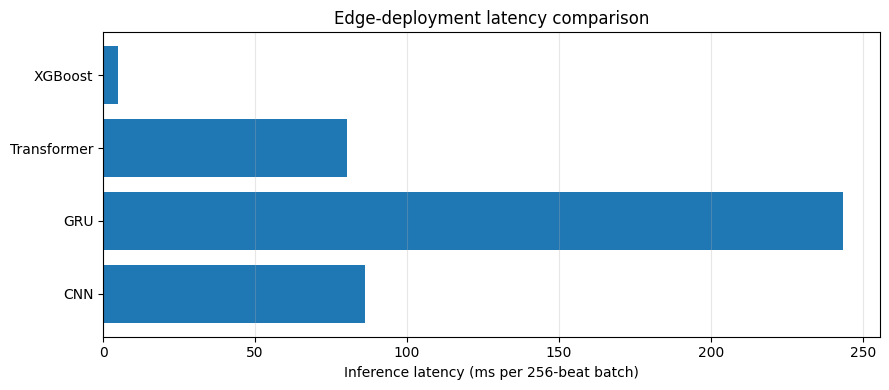

[01:57:22] Fig saved: deployment_latency.png | Table saved: deployment_table.csv


In [16]:
import sys

# ── Model size and latency profiling ─────────────────────────────────────
def model_size_kb(model):
    """Trainable parameter count and approximate fp32 memory footprint."""
    params = model.count_params()
    kb = params * 4 / 1024
    return params, round(kb, 1)

dl_models = {
    'CNN': cnn_model,
    'GRU': gru_model,
    'Transformer': tfm_model,
    'MLP meta': mlp_meta,
}

N_BENCH = min(256, len(X_test_dl))
X_bench = X_test_dl[:N_BENCH]
Xf_bench = X_test_feat_s[:N_BENCH]

def benchmark_latency(fn, n_reps=30):
    for _ in range(2):
        fn()
    t0 = time.perf_counter()
    for _ in range(n_reps):
        fn()
    return (time.perf_counter() - t0) / n_reps * 1000

latencies = {
    'CNN': benchmark_latency(lambda: cnn_model.predict(X_bench, verbose=0)),
    'GRU': benchmark_latency(lambda: gru_model.predict(X_bench, verbose=0)),
    'Transformer': benchmark_latency(lambda: tfm_model.predict(X_bench, verbose=0)),
    'XGBoost': benchmark_latency(lambda: xgb_model.predict_proba(Xf_bench)),
    'MLP meta': benchmark_latency(lambda: mlp_meta.predict(meta_test[:N_BENCH], verbose=0)),
}

# ── Optional TFLite quantisation; the notebook continues if conversion fails ──
tflite_size = np.nan
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(cnn_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def representative_data():
        n_rep = min(512, len(X_train_dl))
        for i in range(0, n_rep, 32):
            yield [X_train_dl[i:i+32].astype(np.float32)]

    converter.representative_dataset = representative_data
    tflite_model = converter.convert()
    tflite_size = len(tflite_model) / 1024
    with open(mdl('cnn_dynamic_quant.tflite'), 'wb') as f:
        f.write(tflite_model)

    interp = tf.lite.Interpreter(model_content=tflite_model)
    interp.allocate_tensors()
    inp_idx = interp.get_input_details()[0]['index']

    def tflite_infer():
        for sample in X_bench[:min(32, len(X_bench))]:
            interp.set_tensor(inp_idx, sample[np.newaxis].astype(np.float32))
            interp.invoke()

    latencies['CNN-TF'] = benchmark_latency(tflite_infer)
    print(f'TF conversion successful: {tflite_size:.1f} KB')
except Exception as e:
    print(f'TF conversion skipped/failed: {e}')

rows = []
for name in ['CNN', 'GRU', 'Transformer', 'XGBoost', 'MLP meta']:
    if name in dl_models:
        params, kb = model_size_kb(dl_models[name])
    else:
        params, kb = 'N/A', 'N/A'
    rows.append({
        'Model': name,
        'Parameters': f'{params:,}' if isinstance(params, int) else params,
        'Approx. size (KB)': kb,
        f'Latency (ms/{N_BENCH} beats)': latencies.get(name, np.nan),
    })
if 'CNN-TF' in latencies:
    p_cnn, _ = model_size_kb(cnn_model)
    rows.append({
        'Model': 'CNN-TF',
        'Parameters': f'{p_cnn:,}',
        'Approx. size (KB)': tflite_size,
        f'Latency (ms/{N_BENCH} beats)': latencies['CNN-TF'],
    })

df_deploy = pd.DataFrame(rows)
print('=== Deployment comparison ===')
print(df_deploy.to_string(index=False))
df_deploy.to_csv(tbl('deployment_table.csv'), index=False)

lat_names = [n for n in ['CNN', 'GRU', 'Transformer', 'XGBoost', 'CNN-TF'] if n in latencies]
lat_vals = [latencies[n] for n in lat_names]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(lat_names, lat_vals)
ax.set_xlabel(f'Inference latency (ms per {N_BENCH}-beat batch)')
ax.set_title('Edge-deployment latency comparison')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(fpath('deployment_latency.png'), dpi=150, bbox_inches='tight')
plt.show()
log('Fig saved: deployment_latency.png | Table saved: deployment_table.csv')


## Section 11 — Final Decision-Support Dashboard

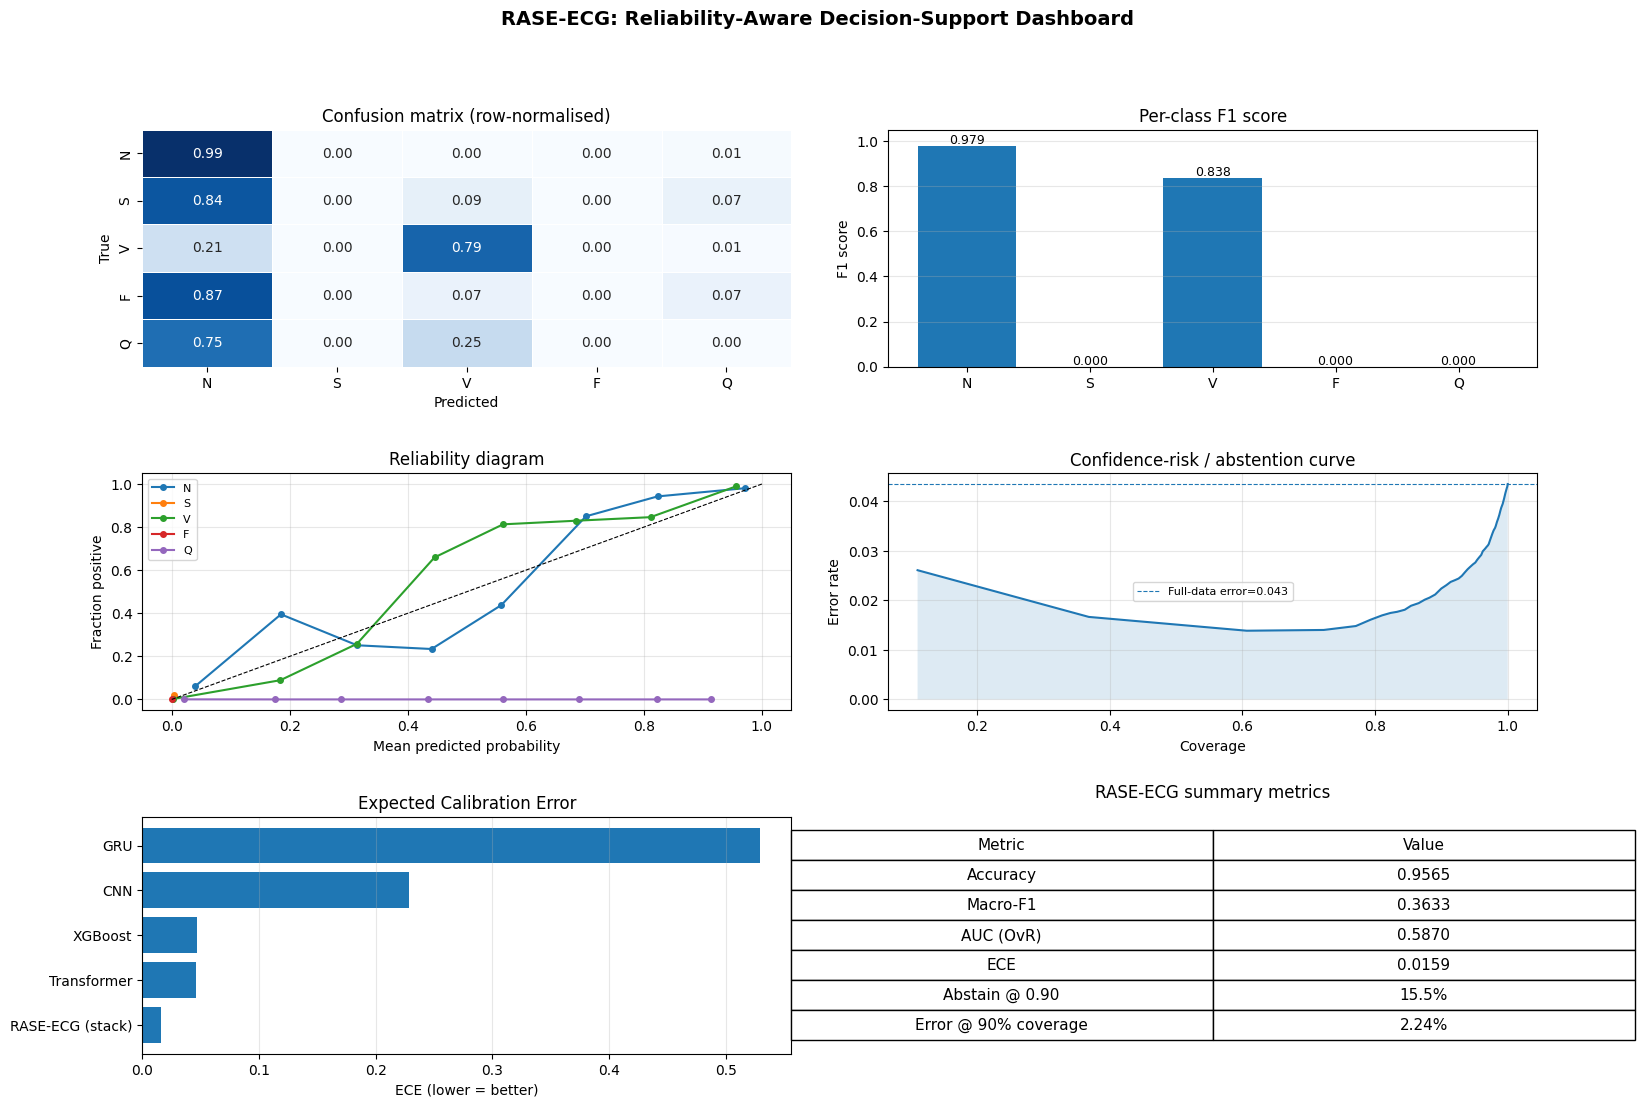

[01:57:31] Fig saved: rase_ecg_dashboard.png
Dashboard saved → /content/drive/MyDrive/Outputs/RASE_ECG/Figures/rase_ecg_dashboard.png


In [17]:
# ── Full dashboard: metrics + calibration + confidence + abstention ───────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('RASE-ECG: Reliability-Aware Decision-Support Dashboard', fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# 1. Confusion matrix
ax1 = fig.add_subplot(gs[0, :2])
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=ax1, cbar=False)
ax1.set_title('Confusion matrix (row-normalised)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# 2. Per-class F1 bar chart
ax2 = fig.add_subplot(gs[0, 2:])
f1_per_class = f1_score(y_test, y_pred, average=None, labels=np.arange(N_CLASSES))
ax2.bar(CLASS_NAMES, f1_per_class)
ax2.set_ylim(0, 1.05)
for i, v in enumerate(f1_per_class):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax2.set_title('Per-class F1 score')
ax2.set_ylabel('F1 score'); ax2.grid(True, axis='y', alpha=0.3)

# 3. Calibration curves
ax3 = fig.add_subplot(gs[1, :2])
for cls_id in range(N_CLASSES):
    y_bin = (y_test == cls_id).astype(int)
    frac_pos, mean_pred = calibration_curve(y_bin, y_pred_proba[:, cls_id], n_bins=8, strategy='uniform')
    ax3.plot(mean_pred, frac_pos, 'o-', label=CLASS_NAMES[cls_id], markersize=4)
ax3.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax3.set_title('Reliability diagram')
ax3.set_xlabel('Mean predicted probability'); ax3.set_ylabel('Fraction positive')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# 4. Confidence-risk curve
ax4 = fig.add_subplot(gs[1, 2:])
ax4.plot(coverage, error_rate, '-', lw=1.5)
ax4.axhline(1 - acc, ls='--', lw=0.8, label=f'Full-data error={1-acc:.3f}')
if len(coverage) > 1:
    ax4.fill_between(coverage, error_rate, alpha=0.15)
ax4.set_title('Confidence-risk / abstention curve')
ax4.set_xlabel('Coverage'); ax4.set_ylabel('Error rate')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

# 5. ECE comparison
ax5 = fig.add_subplot(gs[2, :2])
ece_sorted = dict(sorted(ece_vals.items(), key=lambda x: x[1]))
ax5.barh(list(ece_sorted.keys()), list(ece_sorted.values()))
ax5.set_title('Expected Calibration Error')
ax5.set_xlabel('ECE (lower = better)'); ax5.grid(True, axis='x', alpha=0.3)

# 6. Summary metrics table
ax6 = fig.add_subplot(gs[2, 2:])
ax6.axis('off')
mask_90cov = y_conf >= np.percentile(y_conf, 10)
err_90cov = 100 * (1 - correct[mask_90cov].mean()) if mask_90cov.sum() else np.nan
summary_data = [
    ['Metric', 'Value'],
    ['Accuracy', f'{acc:.4f}'],
    ['Macro-F1', f'{f1m:.4f}'],
    ['AUC (OvR)', f'{auc:.4f}'],
    ['ECE', f'{ece_vals["RASE-ECG (stack)"]:.4f}'],
    ['Abstain @ 0.90', f'{100*(y_conf < 0.90).mean():.1f}%'],
    ['Error @ 90% coverage', f'{err_90cov:.2f}%'],
]
table = ax6.table(cellText=summary_data[1:], colLabels=summary_data[0], loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.3, 1.8)
ax6.set_title('RASE-ECG summary metrics', pad=14)

plt.savefig(fpath('rase_ecg_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
log('Fig saved: rase_ecg_dashboard.png')
print(f'Dashboard saved → {fpath("rase_ecg_dashboard.png")}')


## Final — Write complete summary to Drive log & save notebook copy

In [18]:
import datetime, shutil, glob

# ── Write final summary block to Logs/Outputs_Summary.txt ─────────────────
summary_lines = [
    '',
    '── FINAL RESULTS ────────────────────────────────────────',
    f'  Accuracy        : {acc:.4f}',
    f'  Macro-F1        : {f1m:.4f}',
    f'  AUC (OvR macro) : {auc:.4f}',
    f'  ECE (RASE-ECG)  : {ece_vals["RASE-ECG (stack)"]:.4f}',
    '',
    '── PER-CLASS F1 ─────────────────────────────────────────',
]
for cls_id, name in enumerate(CLASS_NAMES):
    summary_lines.append(f'  {name} ({CLASS_LABELS[cls_id]:>16s}): F1={f1_per_class[cls_id]:.4f}')

summary_lines += [
    '',
    '── ABSTENTION THRESHOLDS ────────────────────────────────',
]
for th in [0.7, 0.9, 0.95]:
    mask = y_conf >= th
    if mask.sum() > 0:
        err = 1.0 - correct[mask].mean()
        cov = mask.mean()
        summary_lines.append(f'  th={th:.2f}: coverage={100*cov:.1f}%  error={100*err:.2f}%')

summary_lines += [
    '',
    '── OUTPUT FILES ─────────────────────────────────────────',
    f'  FIGURES_DIR    : {FIGURES_DIR}',
    '    beat_samples.png',
    '    confusion_matrices.png',
    '    calibration.png',
    '    confidence_risk.png',
    '    entropy_error_separation.png',
    '    shap_meta.png',
    '    gradcam_saliency.png',
    '    deployment_latency.png',
    '    rase_ecg_dashboard.png',
    f'  TABLES_DIR     : {TABLES_DIR}',
    '    model_comparison_reliability.csv',
    '    ece_comparison.csv',
    '    selective_prediction_table.csv',
    '    clinical_operating_modes.csv',
    '    shap_branch_contributions.csv',
    '    deployment_table.csv',
    '    results_comparison.tex',
    f'  MODELS_DIR     : {MODELS_DIR}',
    '    model_cnn.keras',
    '    model_gru.keras',
    '    model_transformer.keras',
    '    model_mlp_meta.keras',
    '    model_xgb.joblib',
    '    model_meta_lr_calibrated.joblib',
    '    scaler_features.joblib',
    '    cnn_dynamic_quant.tflite',
    '    mitbih_cache.npz',
    f'  NOTEBOOK_DIR  : {NOTEBOOK_DIR}',
    '    RASE_ECG_notebook_<timestamp>.ipynb',
    f'  LOGS_DIR : {LOGS_DIR}',
    '    Outputs_Summary.txt',
    '─────────────────────────────────────────────────────────',
]

with open(LOG_PATH, 'a') as f:
    f.write('\n'.join(summary_lines) + '\n')

print('\n'.join(summary_lines))
log(f'Summary written to {LOG_PATH}')

# ── Save a timestamped notebook copy to NOTEBOOK_DIR/Notebook/ ───────────
nb_stamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
nb_dest  = NOTEBOOK_DIR / f'RASE_ECG_notebook_{nb_stamp}.ipynb'
_nb_candidates = glob.glob('/content/*.ipynb')
if _nb_candidates:
    shutil.copy(_nb_candidates[0], nb_dest)
    log(f'Notebook copy → {nb_dest}')
else:
    log('Notebook copy: no .ipynb found in /content/ — save manually via File > Save.')

print(f'\nFolder summary:')
print(f'  Figures  → {FIGURES_DIR}')
print(f'  Tables   → {TABLES_DIR}')
print(f'  Models   → {MODELS_DIR}')
print(f'  Notebook → {NOTEBOOK_DIR}')
print(f'  Logs     → {LOGS_DIR}')


── FINAL RESULTS ────────────────────────────────────────
  Accuracy        : 0.9565
  Macro-F1        : 0.3633
  AUC (OvR macro) : 0.5870
  ECE (RASE-ECG)  : 0.0159

── PER-CLASS F1 ─────────────────────────────────────────
  N (          Normal): F1=0.9789
  S (Supraventricular): F1=0.0000
  V (     Ventricular): F1=0.8377
  F (          Fusion): F1=0.0000
  Q (  Unclassifiable): F1=0.0000

── ABSTENTION THRESHOLDS ────────────────────────────────
  th=0.70: coverage=96.2%  error=2.99%
  th=0.90: coverage=84.5%  error=1.81%
  th=0.95: coverage=77.1%  error=1.48%

── OUTPUT FILES ─────────────────────────────────────────
  FIGURES_DIR    : /content/drive/MyDrive/Outputs/RASE_ECG/Figures
    beat_samples.png
    confusion_matrices.png
    calibration.png
    confidence_risk.png
    entropy_error_separation.png
    shap_meta.png
    gradcam_saliency.png
    deployment_latency.png
    rase_ecg_dashboard.png
  TABLES_DIR     : /content/drive/MyDrive/Outputs/RASE_ECG/Tables
    model_comp

---
## Appendix — Paper-ready results table

The cell below prints a LaTeX-ready comparison table and saves it to `Tables/results_comparison.tex`.

In [19]:
# ── LaTeX results table → Tables/results_comparison.tex ──────────────────
# Uses df_cmp from Section 7 and ece_vals from Section 8.
latex_rows = []
for _, row in df_cmp.iterrows():
    name = row['Model']
    ece = ece_vals.get(name, np.nan)
    bold = name == 'RASE-ECG (stack)'
    def fmt(v, decimals=4):
        if pd.isna(v):
            s = '--'
        else:
            s = f'{float(v):.{decimals}f}'
        return f'\\textbf{{{s}}}' if bold else s
    model_name = f'\\textbf{{{name}}}' if bold else name
    latex_rows.append(
        f'  {model_name:30s} & {fmt(row["Accuracy"])} & {fmt(row["Macro-F1"])} & {fmt(row["AUC-OvR"])} & {fmt(ece)} & {fmt(row["Brier"])} \\\\'
    )

latex_content = '\n'.join([
    '\\begin{table}[h]',
    '\\centering',
    '\\caption{Predictive performance and reliability comparison on the MIT-BIH test set}',
    '\\begin{tabular}{lccccc}',
    '\\toprule',
    '  Model & Accuracy & Macro-F1 & AUC-OvR & ECE & Brier \\\\',
    '\\midrule',
    *latex_rows,
    '\\bottomrule',
    '\\end{tabular}',
    '\\end{table}',
])

print(latex_content)
tex_path = tbl('results_comparison.tex')
with open(tex_path, 'w', encoding='utf-8') as f:
    f.write(latex_content)
log(f'LaTeX table saved → {tex_path}')


\begin{table}[h]
\centering
\caption{Predictive performance and reliability comparison on the MIT-BIH test set}
\begin{tabular}{lccccc}
\toprule
  Model & Accuracy & Macro-F1 & AUC-OvR & ECE & Brier \\
\midrule
  \textbf{RASE-ECG (stack)}      & \textbf{0.9565} & \textbf{0.3633} & \textbf{0.5870} & \textbf{0.0159} & \textbf{0.0774} \\
  XGBoost                        & 0.8980 & 0.3170 & 0.7484 & 0.0466 & 0.1691 \\
  Transformer                    & 0.7389 & 0.3019 & 0.7599 & 0.0458 & 0.3575 \\
  CNN                            & 0.6357 & 0.1965 & 0.6963 & 0.2282 & 0.5712 \\
  GRU                            & 0.0480 & 0.0183 & 0.6340 & 0.5296 & 1.0158 \\
\bottomrule
\end{tabular}
\end{table}
[01:57:46] LaTeX table saved → /content/drive/MyDrive/Outputs/RASE_ECG/Tables/results_comparison.tex
